In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Plots for computation times

In [86]:
filename = "data/computation_times.csv"
data = pd.read_csv(filename)
save_dir = "plots/mesh"

os.makedirs(save_dir, exist_ok=True)

data.head()

,N,problem,solver,time
0,4,mass,SparseLU,0.000120
1,4,mass,SparseLU,0.000041
2,4,mass,SparseLU,0.000027
3,4,mass,SparseLU,0.000024
4,4,mass,SparseLU,0.000022


In [87]:
average_data = data.groupby(['N', 'problem', 'solver'])['time'].mean().reset_index()
average_data = average_data[average_data['N'] != 4]
average_data.head()

,N,problem,solver,time
9,8,diffusion_transport,MumpsBLR,0.002711
10,8,diffusion_transport,MumpsLU,0.002625
11,8,diffusion_transport,SparseLU,0.000151
12,8,laplacian,MumpsBLR,0.002530
13,8,laplacian,MumpsLU,0.002411


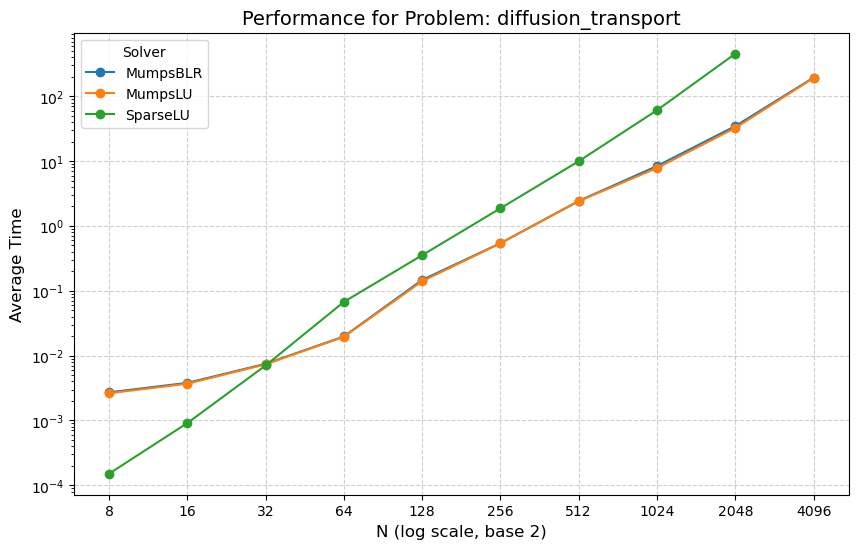

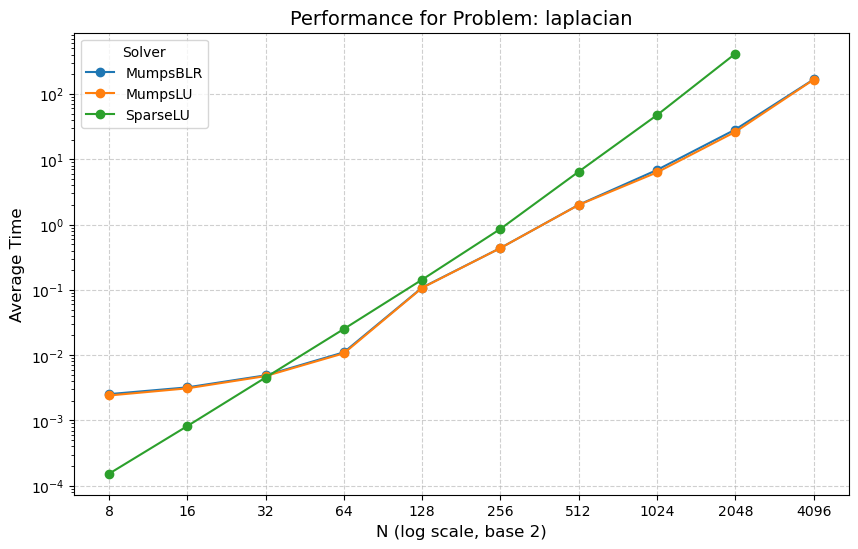

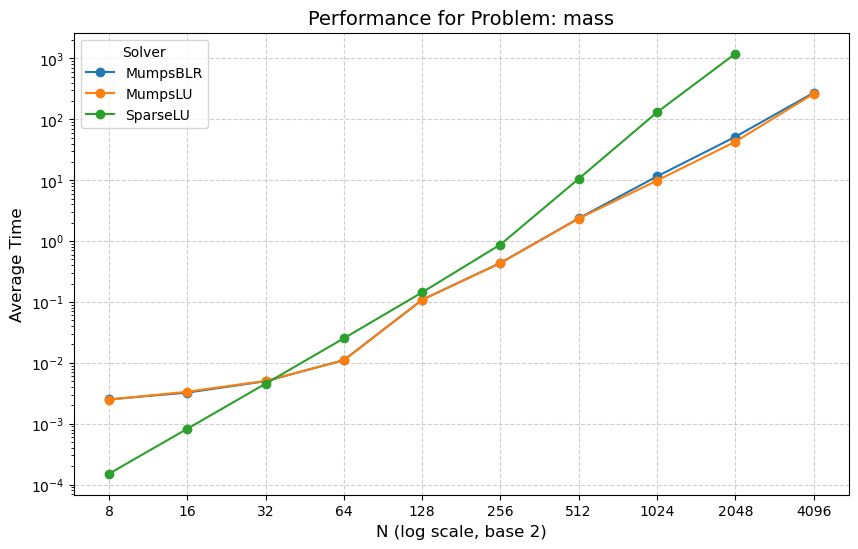

In [88]:
problems = average_data['problem'].unique()
for problem in problems:
    plt.figure(figsize=(10, 6))
    problem_data = average_data[average_data['problem'] == problem]
    
    solvers = problem_data['solver'].unique()
    for solver in solvers:
        solver_data = problem_data[problem_data['solver'] == solver]
        plt.plot(solver_data['N'], solver_data['time'], marker='o', label=solver)

    # Configure the plot
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.xticks(ticks=sorted(problem_data['N'].unique()), labels=sorted(problem_data['N'].unique()), fontsize=10)
    plt.title(f"Performance for Problem: {problem}", fontsize=14)
    plt.xlabel("N (log scale, base 2)", fontsize=12)
    plt.ylabel("Average Time", fontsize=12)
    plt.legend(title="Solver")
    plt.grid(True, linestyle='--', alpha=0.6)

    filename = os.path.join(save_dir, problem + ".png")
    plt.savefig(filename)
    
    # Show or save the plot
    plt.show()

In [89]:
for problem in problems:
    problem_data = average_data[average_data['problem'] == problem]
    solver_order = ['SparseLU', 'MumpsLU', 'MumpsBLR']
    pivot_table = problem_data.pivot_table(index='N', columns='solver', values='time').reindex(columns=solver_order).reset_index()
    output_csv_path = f'averaged_results_{problem}.csv'
    pivot_table.to_csv(output_csv_path, index=False)

# Plots for spd computation times

In [90]:
filename = "data/computation_times_spd.csv"
data = pd.read_csv(filename)
save_dir = "plots/mesh_spd"

os.makedirs(save_dir, exist_ok=True)

data.head()

,N,problem,solver,time
0,4,mass,SimplicialLLT,0.000078
1,4,mass,SimplicialLLT,0.000015
2,4,mass,SimplicialLLT,0.000012
3,4,mass,SimplicialLLT,0.000010
4,4,mass,SimplicialLLT,0.000010


In [91]:
average_data = data.groupby(['N', 'problem', 'solver'])['time'].mean().reset_index()
average_data = average_data[average_data['N'] != 4]
average_data.head()

,N,problem,solver,time
2,8,mass,MumpsLDLT,0.002471
3,8,mass,SimplicialLLT,0.000042
4,16,mass,MumpsLDLT,0.004201
5,16,mass,SimplicialLLT,0.000236
6,32,mass,MumpsLDLT,0.004372


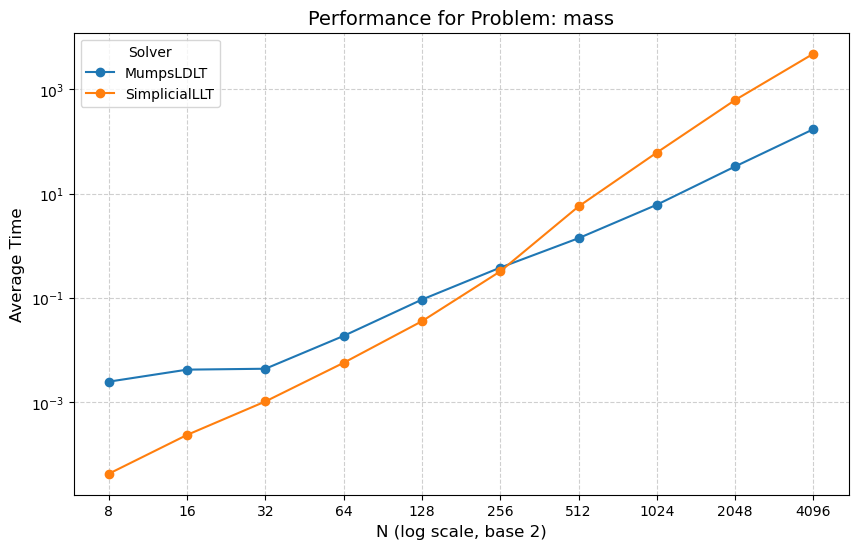

In [92]:
problems = average_data['problem'].unique()
for problem in problems:
    plt.figure(figsize=(10, 6))
    problem_data = average_data[average_data['problem'] == problem]
    solvers = problem_data['solver'].unique()
    for solver in solvers:
        solver_data = problem_data[problem_data['solver'] == solver]
        plt.plot(solver_data['N'], solver_data['time'], marker='o', label=solver)

    # Configure the plot
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.xticks(ticks=sorted(problem_data['N'].unique()), labels=sorted(problem_data['N'].unique()), fontsize=10)
    plt.title(f"Performance for Problem: {problem}", fontsize=14)
    plt.xlabel("N (log scale, base 2)", fontsize=12)
    plt.ylabel("Average Time", fontsize=12)
    plt.legend(title="Solver")
    plt.grid(True, linestyle='--', alpha=0.6)

    filename = os.path.join(save_dir, problem + ".png")
    plt.savefig(filename)
    
    # Show or save the plot
    plt.show()

In [93]:
for problem in problems:
    problem_data = average_data[average_data['problem'] == problem]
    solver_order = ['SimplicialLLT', 'MumpsLDLT']
    pivot_table = problem_data.pivot_table(index='N', columns='solver', values='time').reindex(columns=solver_order).reset_index()
    output_csv_path = f'averaged_results_spd_{problem}.csv'
    pivot_table.to_csv(output_csv_path, index=False)

# Plots for wrapped vs non-wrapped

In [94]:
filename = "data/computation_times_raw.csv"
data = pd.read_csv(filename)
save_dir = "plots/mesh_raw"

os.makedirs(save_dir, exist_ok=True)

data.head()

,N,problem,solver,time
0,4,mass,Wrapped,0.208539
1,4,mass,Wrapped,0.002370
2,4,mass,Wrapped,0.002186
3,4,mass,Wrapped,0.002284
4,4,mass,Wrapped,0.002212


In [95]:
average_data = data.groupby(['N', 'problem', 'solver'])['time'].mean().reset_index()
average_data = average_data[average_data['N'] != 4]
average_data.head()

,N,problem,solver,time
6,8,diffusion_transport,Non-wrapped,0.002212
7,8,diffusion_transport,Wrapped,0.002489
8,8,laplacian,Non-wrapped,0.002074
9,8,laplacian,Wrapped,0.002354
10,8,mass,Non-wrapped,0.002056


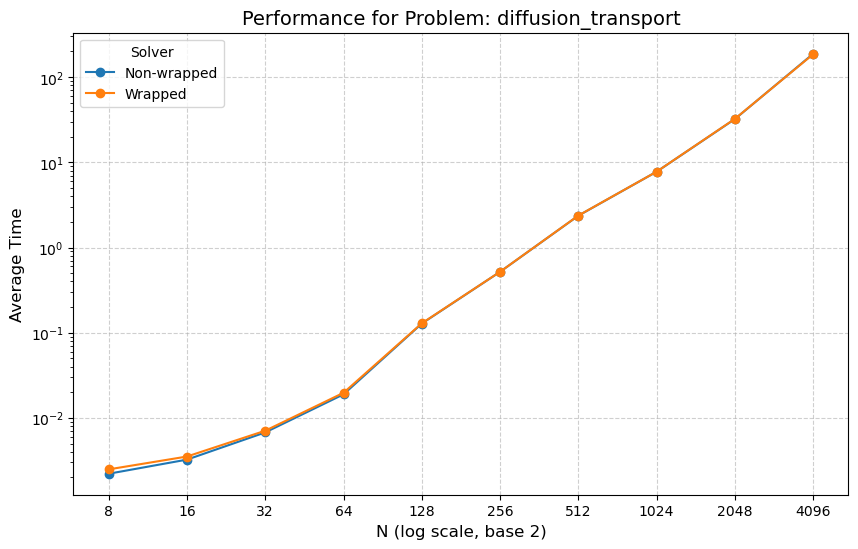

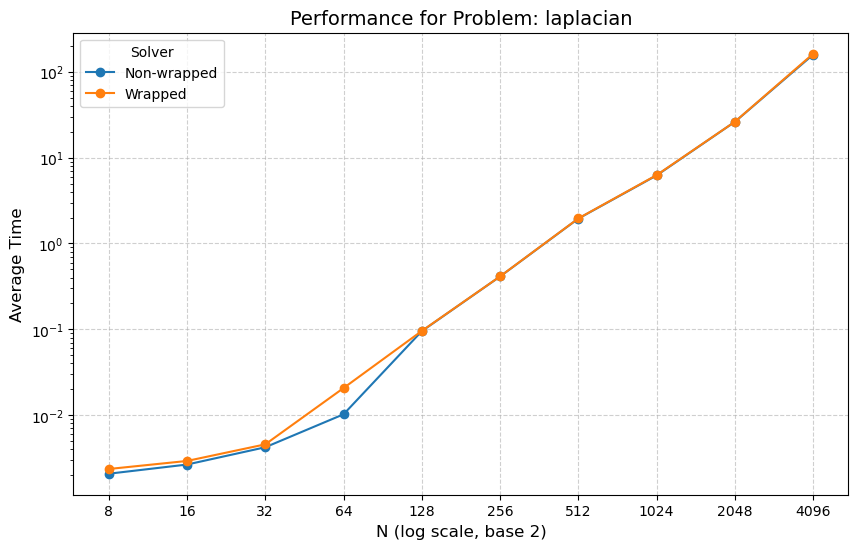

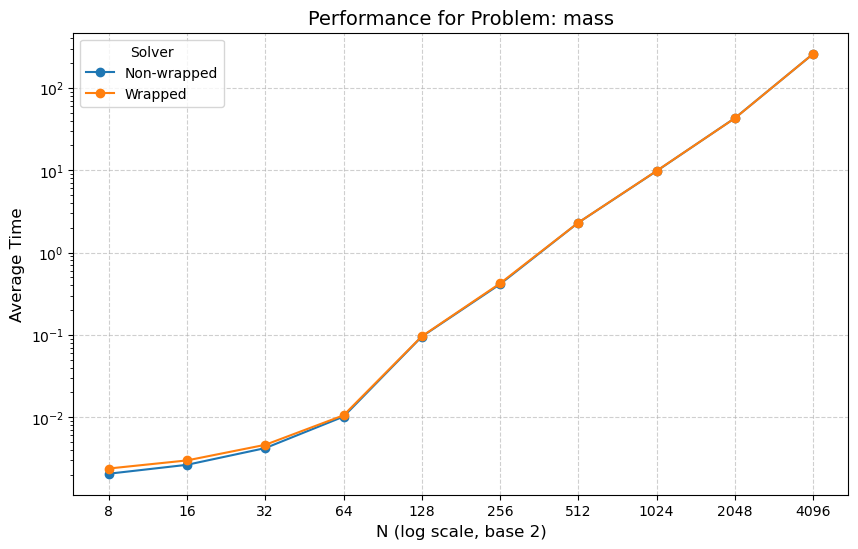

In [96]:
problems = average_data['problem'].unique()
for problem in problems:
    plt.figure(figsize=(10, 6))
    problem_data = average_data[average_data['problem'] == problem]
    solvers = problem_data['solver'].unique()
    for solver in solvers:
        solver_data = problem_data[problem_data['solver'] == solver]
        plt.plot(solver_data['N'], solver_data['time'], marker='o', label=solver)

    # Configure the plot
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.xticks(ticks=sorted(problem_data['N'].unique()), labels=sorted(problem_data['N'].unique()), fontsize=10)
    plt.title(f"Performance for Problem: {problem}", fontsize=14)
    plt.xlabel("N (log scale, base 2)", fontsize=12)
    plt.ylabel("Average Time", fontsize=12)
    plt.legend(title="Solver")
    plt.grid(True, linestyle='--', alpha=0.6)

    filename = os.path.join(save_dir, problem + ".png")
    plt.savefig(filename)
    
    # Show or save the plot
    plt.show()

In [97]:
for problem in problems:
    problem_data = average_data[average_data['problem'] == problem]
    solver_order = ['Non-wrapped', 'Wrapped']
    pivot_table = problem_data.pivot_table(index='N', columns='solver', values='time').reindex(columns=solver_order).reset_index()
    output_csv_path = f'averaged_results_raw_{problem}.csv'
    pivot_table.to_csv(output_csv_path, index=False)